In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt
sns.set()
sns.set_palette(palette='deep')

In [3]:
media=pd.read_csv("Social Media Data for DSBA.csv")

In [4]:
media.head()

,UserID,Taken_product,Yearly_avg_view_on_travel_page,preferred_device,total_likes_on_outstation_checkin_given,yearly_avg_Outstation_checkins,member_in_family,preferred_location_type,Yearly_avg_comment_on_travel_page,total_likes_on_outofstation_checkin_received,week_since_last_outstation_checkin,following_company_page,montly_avg_comment_on_company_page,working_flag,travelling_network_rating,Adult_flag,Daily_Avg_mins_spend_on_traveling_page
0,1000001,Yes,307.0,iOS and Android,38570.0,1,2,Financial,94.0,5993,8,Yes,11,No,1,0,8
1,1000002,No,367.0,iOS,9765.0,1,1,Financial,61.0,5130,1,No,23,Yes,4,1,10
2,1000003,Yes,277.0,iOS and Android,48055.0,1,2,Other,92.0,2090,6,Yes,15,No,2,0,7
3,1000004,No,247.0,iOS,48720.0,1,4,Financial,56.0,2909,1,Yes,11,No,3,0,8
4,1000005,No,202.0,iOS and Android,20685.0,1,1,Medical,40.0,3468,9,No,12,No,4,1,6


In [4]:
media.shape

(11760, 17)

In [5]:
media.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11760 entries, 0 to 11759
Data columns (total 17 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   UserID                                        11760 non-null  int64  
 1   Taken_product                                 11760 non-null  object 
 2   Yearly_avg_view_on_travel_page                11179 non-null  float64
 3   preferred_device                              11707 non-null  object 
 4   total_likes_on_outstation_checkin_given       11379 non-null  float64
 5   yearly_avg_Outstation_checkins                11685 non-null  object 
 6   member_in_family                              11760 non-null  object 
 7   preferred_location_type                       11729 non-null  object 
 8   Yearly_avg_comment_on_travel_page             11554 non-null  float64
 9   total_likes_on_outofstation_checkin_received  11760 non-null 

In [5]:
media_na=media.isna().sum()
media_na[media_na.values>0].sort_values(ascending=False)

Yearly_avg_view_on_travel_page             581
total_likes_on_outstation_checkin_given    381
Yearly_avg_comment_on_travel_page          206
following_company_page                     103
yearly_avg_Outstation_checkins              75
preferred_device                            53
preferred_location_type                     31
dtype: int64

In [5]:
#yearly_avg_view 581, total_likes_on 381, yearly_avg_comment 206 : all these features have high percentage of missing values and hence we are dropping these from analysis. we ae dropping them to make sure other valid observations do not get eliminated when we remove or impute na values


In [6]:
media.drop(["Yearly_avg_view_on_travel_page","total_likes_on_outstation_checkin_given","Yearly_avg_comment_on_travel_page"],axis="columns",inplace=True)

In [7]:
media.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11760 entries, 0 to 11759
Data columns (total 14 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   UserID                                        11760 non-null  int64 
 1   Taken_product                                 11760 non-null  object
 2   preferred_device                              11707 non-null  object
 3   yearly_avg_Outstation_checkins                11685 non-null  object
 4   member_in_family                              11760 non-null  object
 5   preferred_location_type                       11729 non-null  object
 6   total_likes_on_outofstation_checkin_received  11760 non-null  int64 
 7   week_since_last_outstation_checkin            11760 non-null  int64 
 8   following_company_page                        11657 non-null  object
 9   montly_avg_comment_on_company_page            11760 non-null  int64 
 10

In [10]:
media.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UserID,11760.0,NaN,NaN,NaN,1005880.5,3394.963917,1000001.0,1002940.75,1005880.5,1008820.25,1011760.0
Taken_product,11760,2,No,9864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
preferred_device,11707,10,Tab,4172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
yearly_avg_Outstation_checkins,11685,30,1,4543,NaN,NaN,NaN,NaN,NaN,NaN,NaN
member_in_family,11760,7,3,4561,NaN,NaN,NaN,NaN,NaN,NaN,NaN
preferred_location_type,11729,15,Beach,2424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_likes_on_outofstation_checkin_received,11760.0,NaN,NaN,NaN,6531.699065,4706.613785,1009.0,2940.75,4948.0,8393.25,20065.0
week_since_last_outstation_checkin,11760.0,NaN,NaN,NaN,3.203571,2.616365,0.0,1.0,3.0,5.0,11.0
following_company_page,11657,4,No,8355,NaN,NaN,NaN,NaN,NaN,NaN,NaN
montly_avg_comment_on_company_page,11760.0,NaN,NaN,NaN,28.661565,48.660504,11.0,17.0,22.0,27.0,500.0


In [8]:
media["Taken_product"].value_counts()

No     9864
Yes    1896
Name: Taken_product, dtype: int64

In [6]:
media.yearly_avg_Outstation_checkins.unique()

array(['1', '24', '23', '27', '16', '15', '26', '19', '21', '11', '10',
       '25', '12', '18', '29', nan, '22', '14', '20', '28', '17', '13',
       '*', '5', '8', '2', '3', '9', '7', '6', '4'], dtype=object)

In [13]:
media.member_in_family.unique()

array(['2', '1', '4', 'Three', '3', '5', '10'], dtype=object)

In [7]:
media["member_in_family"]=media["member_in_family"].apply(lambda x:x.replace("Three","3"))

In [9]:
media.member_in_family.unique()


array(['2', '1', '4', '3', '5', '10'], dtype=object)

In [8]:
media["member_in_family"]=media["member_in_family"].astype("int")
media.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11760 entries, 0 to 11759
Data columns (total 14 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   UserID                                        11760 non-null  int64 
 1   Taken_product                                 11760 non-null  object
 2   preferred_device                              11707 non-null  object
 3   yearly_avg_Outstation_checkins                11685 non-null  object
 4   member_in_family                              11760 non-null  int32 
 5   preferred_location_type                       11729 non-null  object
 6   total_likes_on_outofstation_checkin_received  11760 non-null  int64 
 7   week_since_last_outstation_checkin            11760 non-null  int64 
 8   following_company_page                        11657 non-null  object
 9   montly_avg_comment_on_company_page            11760 non-null  int64 
 10

In [23]:

media["yearly_avg_Outstation_checkins"].unique()

array(['1', '24', '23', '27', '16', '15', '26', '19', '21', '11', '10',
       '25', '12', '18', '29', nan, '22', '14', '20', '28', '17', '13',
       '*', '5', '8', '2', '3', '9', '7', '6', '4'], dtype=object)

In [9]:
media["yearly_avg_Outstation_checkins"]=media["yearly_avg_Outstation_checkins"].str.replace("*","")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8644\309384011.py:1: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  media["yearly_avg_Outstation_checkins"]=media["yearly_avg_Outstation_checkins"].str.replace("*","")


In [10]:
media["yearly_avg_Outstation_checkins"]=media["yearly_avg_Outstation_checkins"].str.replace("nan","")

In [12]:
media["yearly_avg_Outstation_checkins"].unique()

array(['1', '24', '23', '27', '16', '15', '26', '19', '21', '11', '10',
       '25', '12', '18', '29', nan, '22', '14', '20', '28', '17', '13',
       '', '5', '8', '2', '3', '9', '7', '6', '4'], dtype=object)

In [11]:
media["yearly_avg_Outstation_checkins"].replace('',np.NaN,inplace=True)

In [14]:
media["yearly_avg_Outstation_checkins"].unique()

array(['1', '24', '23', '27', '16', '15', '26', '19', '21', '11', '10',
       '25', '12', '18', '29', nan, '22', '14', '20', '28', '17', '13',
       '5', '8', '2', '3', '9', '7', '6', '4'], dtype=object)

In [12]:
from sklearn.impute import SimpleImputer

In [13]:
media1=media["yearly_avg_Outstation_checkins"]

In [14]:
media["yearly_avg_Outstation_checkins"]=media["yearly_avg_Outstation_checkins"].astype("float")

In [17]:
media.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11760 entries, 0 to 11759
Data columns (total 14 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   UserID                                        11760 non-null  int64  
 1   Taken_product                                 11760 non-null  object 
 2   preferred_device                              11707 non-null  object 
 3   yearly_avg_Outstation_checkins                11684 non-null  float64
 4   member_in_family                              11760 non-null  int32  
 5   preferred_location_type                       11729 non-null  object 
 6   total_likes_on_outofstation_checkin_received  11760 non-null  int64  
 7   week_since_last_outstation_checkin            11760 non-null  int64  
 8   following_company_page                        11657 non-null  object 
 9   montly_avg_comment_on_company_page            11760 non-null 

In [15]:
df_num=media.select_dtypes(["float64","int32","int64"])
df_cat=media.select_dtypes(["object"])

In [16]:
df_num.info()
df_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11760 entries, 0 to 11759
Data columns (total 9 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   UserID                                        11760 non-null  int64  
 1   yearly_avg_Outstation_checkins                11684 non-null  float64
 2   member_in_family                              11760 non-null  int32  
 3   total_likes_on_outofstation_checkin_received  11760 non-null  int64  
 4   week_since_last_outstation_checkin            11760 non-null  int64  
 5   montly_avg_comment_on_company_page            11760 non-null  int64  
 6   travelling_network_rating                     11760 non-null  int64  
 7   Adult_flag                                    11760 non-null  int64  
 8   Daily_Avg_mins_spend_on_traveling_page        11760 non-null  int64  
dtypes: float64(1), int32(1), int64(7)
memory usage: 781.1 KB
<clas

In [17]:
imputer=SimpleImputer(missing_values=np.nan,strategy="median")

In [18]:
df_num=pd.DataFrame(imputer.fit_transform(df_num),columns=df_num.columns)

In [20]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11760 entries, 0 to 11759
Data columns (total 9 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   UserID                                        11760 non-null  float64
 1   yearly_avg_Outstation_checkins                11760 non-null  float64
 2   member_in_family                              11760 non-null  float64
 3   total_likes_on_outofstation_checkin_received  11760 non-null  float64
 4   week_since_last_outstation_checkin            11760 non-null  float64
 5   montly_avg_comment_on_company_page            11760 non-null  float64
 6   travelling_network_rating                     11760 non-null  float64
 7   Adult_flag                                    11760 non-null  float64
 8   Daily_Avg_mins_spend_on_traveling_page        11760 non-null  float64
dtypes: float64(9)
memory usage: 827.0 KB


In [52]:
media["preferred_device"].value_counts()

Tab                4172
iOS and Android    4134
Laptop             1108
iOS                1095
Mobile              600
Android             315
Android OS          145
ANDROID             134
Other                 2
Others                2
Name: preferred_device, dtype: int64

In [53]:
media["preferred_location_type"].value_counts()

Beach              2424
Financial          2409
Historical site    1856
Medical            1845
Other               643
Big Cities          636
Social media        633
Trekking            528
Entertainment       516
Hill Stations       108
Tour  Travel         60
Tour and Travel      47
Game                 12
OTT                   7
Movie                 5
Name: preferred_location_type, dtype: int64

In [54]:
media["following_company_page"].value_counts()

No     8355
Yes    3285
1        12
0         5
Name: following_company_page, dtype: int64

In [19]:
media["preferred_location_type"].replace("Tour Travel","Tour and Travel",inplace=True)

In [28]:
media["preferred_location_type"].value_counts()

Beach              2424
Financial          2409
Historical site    1856
Medical            1845
Other               643
Big Cities          636
Social media        633
Trekking            528
Entertainment       516
Hill Stations       108
Tour  Travel         60
Tour and Travel      47
Game                 12
OTT                   7
Movie                 5
Name: preferred_location_type, dtype: int64

In [20]:
media["preferred_location_type"]=media["preferred_location_type"].str.replace("Tour  Travel","Tour and Travel")

In [30]:
media["preferred_location_type"].value_counts()

Beach              2424
Financial          2409
Historical site    1856
Medical            1845
Other               643
Big Cities          636
Social media        633
Trekking            528
Entertainment       516
Hill Stations       108
Tour and Travel     107
Game                 12
OTT                   7
Movie                 5
Name: preferred_location_type, dtype: int64

In [31]:
media[media["following_company_page"]=="1"]

,UserID,Taken_product,preferred_device,yearly_avg_Outstation_checkins,member_in_family,preferred_location_type,total_likes_on_outofstation_checkin_received,week_since_last_outstation_checkin,following_company_page,montly_avg_comment_on_company_page,working_flag,travelling_network_rating,Adult_flag,Daily_Avg_mins_spend_on_traveling_page
2356,1002357,No,iOS and Android,1.0,3,Medical,3579,0,1,21,Yes,1,1,12
2382,1002383,No,iOS and Android,1.0,2,Financial,2875,1,1,20,Yes,2,0,8
2431,1002432,No,iOS,1.0,4,Financial,4249,1,1,11,No,2,0,9
2479,1002480,No,iOS and Android,1.0,3,Medical,19701,3,1,21,Yes,3,1,32
2528,1002529,Yes,iOS and Android,24.0,4,Medical,4599,0,1,23,Yes,3,0,16
2580,1002581,Yes,iOS and Android,1.0,3,Financial,2074,1,1,12,No,4,1,1
2631,1002632,No,iOS and Android,1.0,2,Medical,7756,3,1,19,No,4,1,10
2683,1002684,Yes,iOS and Android,1.0,3,Financial,2275,1,1,21,Yes,2,1,3
2684,1002685,No,iOS and Android,1.0,3,Financial,7879,1,1,19,No,2,1,9
2686,1002687,No,iOS and Android,1.0,3,Medical,7847,1,1,17,No,1,1,10


In [21]:
media["following_company_page"]=media["following_company_page"].str.replace("yes","Yes")

In [22]:
media["following_company_page"]=media["following_company_page"].str.replace("no","No")

In [23]:
media["following_company_page"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 11760 entries, 0 to 11759
Series name: following_company_page
Non-Null Count  Dtype 
--------------  ----- 
11657 non-null  object
dtypes: object(1)
memory usage: 92.0+ KB


In [28]:
df_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11760 entries, 0 to 11759
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Taken_product            11760 non-null  object
 1   preferred_device         11707 non-null  object
 2   preferred_location_type  11729 non-null  object
 3   following_company_page   11657 non-null  object
 4   working_flag             11760 non-null  object
dtypes: object(5)
memory usage: 459.5+ KB


In [24]:
media["preferred_device"]=np.where(media["preferred_device"]=="Laptop","Laptop","Not Laptop")

In [27]:
media["preferred_device"].value_counts()

Not Laptop    10652
Laptop         1108
Name: preferred_device, dtype: int64

In [25]:
df_num.info()
df_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11760 entries, 0 to 11759
Data columns (total 9 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   UserID                                        11760 non-null  float64
 1   yearly_avg_Outstation_checkins                11760 non-null  float64
 2   member_in_family                              11760 non-null  float64
 3   total_likes_on_outofstation_checkin_received  11760 non-null  float64
 4   week_since_last_outstation_checkin            11760 non-null  float64
 5   montly_avg_comment_on_company_page            11760 non-null  float64
 6   travelling_network_rating                     11760 non-null  float64
 7   Adult_flag                                    11760 non-null  float64
 8   Daily_Avg_mins_spend_on_traveling_page        11760 non-null  float64
dtypes: float64(9)
memory usage: 827.0 KB
<class 'pandas.core.frame

In [26]:
df_cat=media.select_dtypes(["object"])

In [27]:
df_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11760 entries, 0 to 11759
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Taken_product            11760 non-null  object
 1   preferred_device         11760 non-null  object
 2   preferred_location_type  11729 non-null  object
 3   following_company_page   11657 non-null  object
 4   working_flag             11760 non-null  object
dtypes: object(5)
memory usage: 459.5+ KB


In [84]:
media["following_company_page"].value_counts()

No     8360
Yes    3297
Name: following_company_page, dtype: int64

In [28]:
df=pd.concat([df_num,df_cat],axis=1,join="inner")

In [29]:
df.shape

(11760, 14)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11760 entries, 0 to 11759
Data columns (total 14 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   UserID                                        11760 non-null  float64
 1   yearly_avg_Outstation_checkins                11760 non-null  float64
 2   member_in_family                              11760 non-null  float64
 3   total_likes_on_outofstation_checkin_received  11760 non-null  float64
 4   week_since_last_outstation_checkin            11760 non-null  float64
 5   montly_avg_comment_on_company_page            11760 non-null  float64
 6   travelling_network_rating                     11760 non-null  float64
 7   Adult_flag                                    11760 non-null  float64
 8   Daily_Avg_mins_spend_on_traveling_page        11760 non-null  float64
 9   Taken_product                                 11760 non-null 

In [90]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
UserID,11760.0,1.005880e+06,3394.963917,1000001.0,1002940.75,1005880.5,1008820.25,1011760.0
yearly_avg_Outstation_checkins,11760.0,8.223554e+00,8.644327,1.0,1.00,4.0,14.00,29.0
member_in_family,11760.0,2.921344e+00,1.044883,1.0,2.00,3.0,4.00,10.0
total_likes_on_outofstation_checkin_received,11760.0,6.531699e+03,4706.613785,1009.0,2940.75,4948.0,8393.25,20065.0
week_since_last_outstation_checkin,11760.0,3.203571e+00,2.616365,0.0,1.00,3.0,5.00,11.0
montly_avg_comment_on_company_page,11760.0,2.866156e+01,48.660504,11.0,17.00,22.0,27.00,500.0
travelling_network_rating,11760.0,2.712245e+00,1.080887,1.0,2.00,3.0,4.00,4.0
Adult_flag,11760.0,7.938776e-01,0.851823,0.0,0.00,1.0,1.00,3.0
Daily_Avg_mins_spend_on_traveling_page,11760.0,1.381743e+01,9.070657,0.0,8.00,12.0,18.00,270.0


In [30]:
#creating target variable
df['Taken_product'] = np.where((df['Taken_product'] == "No"), 0, 1)

In [29]:
df[['Taken_product',"preferred_device"]].head(10)

,Taken_product,preferred_device
0,1,Not Laptop
1,0,Not Laptop
2,1,Not Laptop
3,0,Not Laptop
4,0,Not Laptop
5,0,Not Laptop
6,0,Not Laptop
7,0,Not Laptop
8,0,Not Laptop
9,0,Not Laptop


In [35]:
df["Taken_product"].value_counts(normalize=True)

0    0.838776
1    0.161224
Name: Taken_product, dtype: float64

<AxesSubplot:>

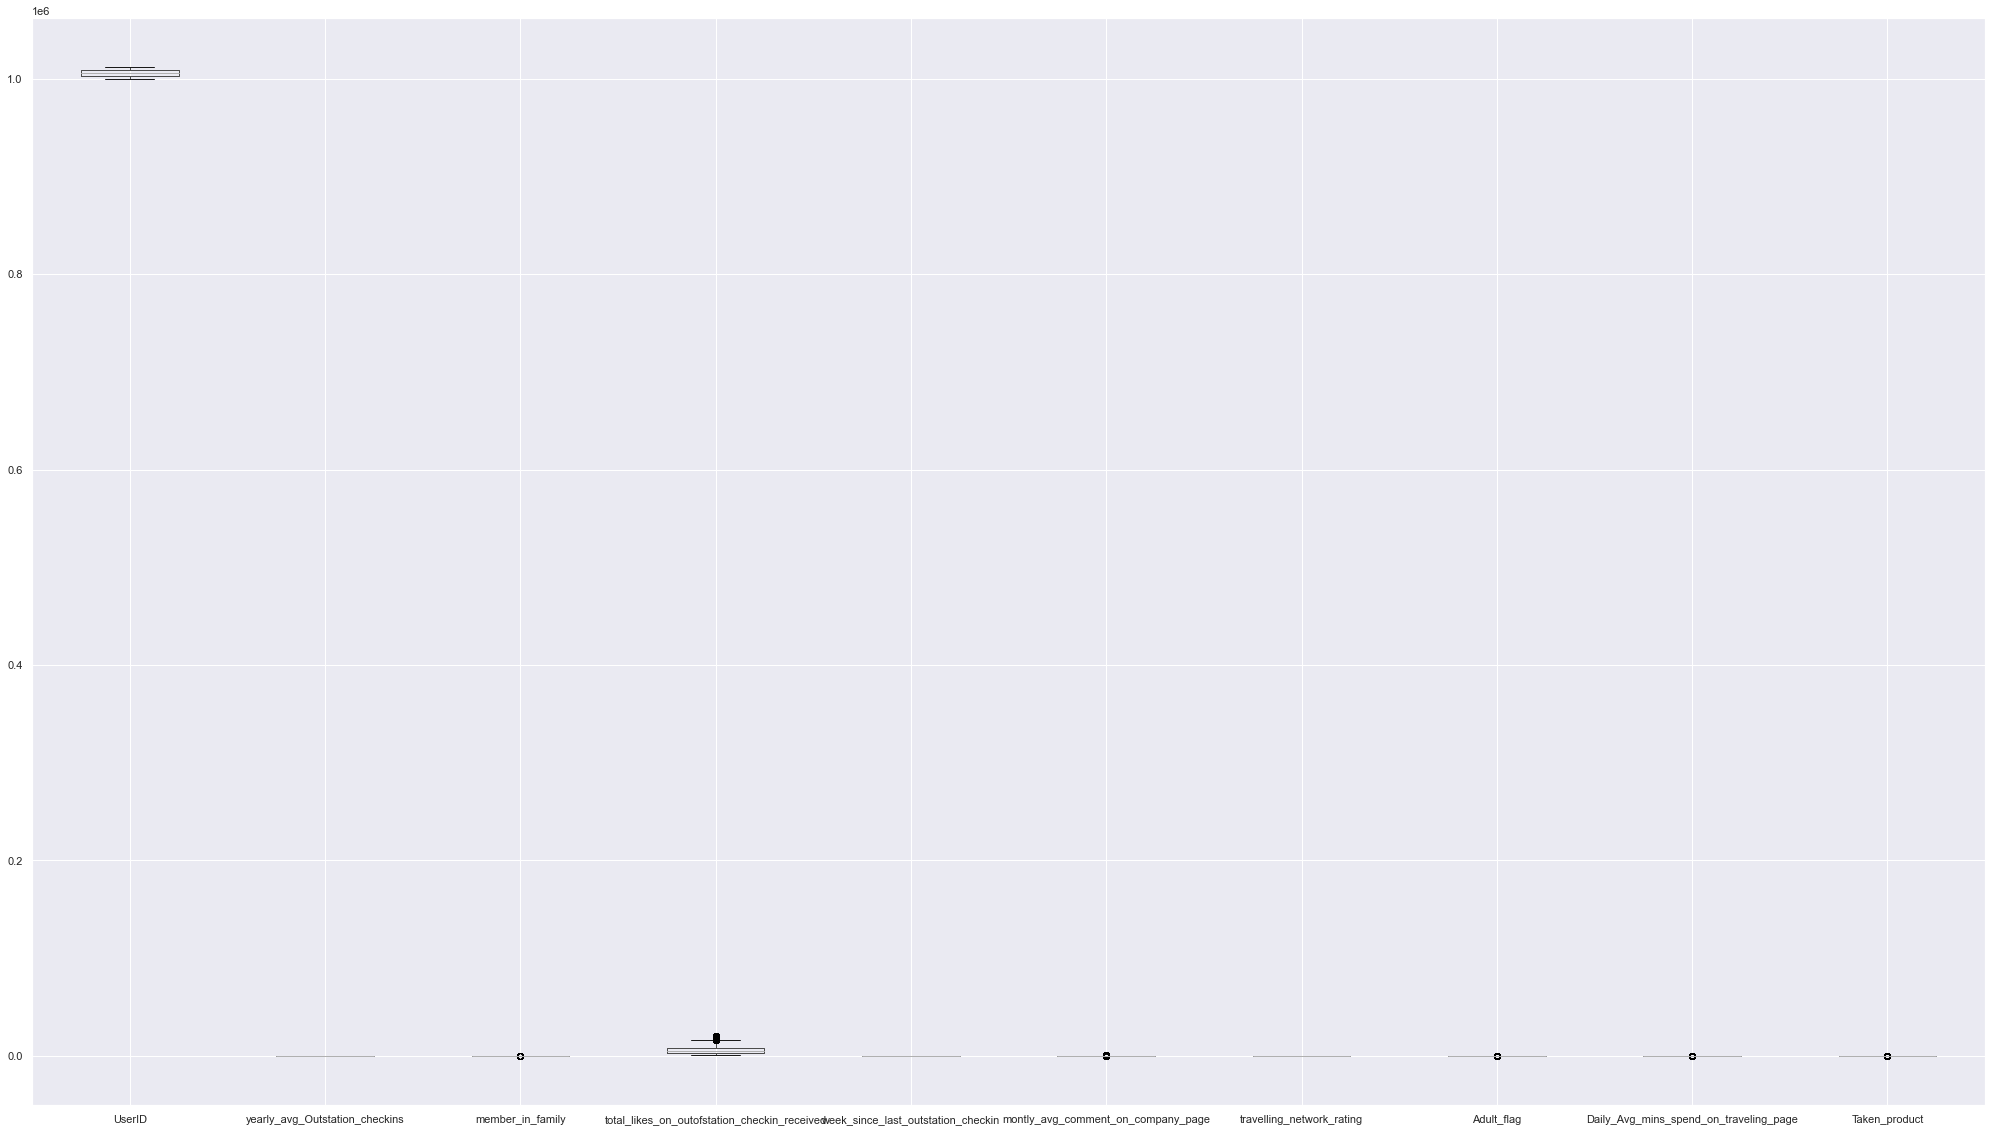

In [101]:
plt.figure(figsize=(35,20))
df.boxplot()

(array([4543.,  844.,  336.,  256.,  261.,  236.,  336.,  396.,  340.,
         682.,  229.,  159.,  150.,  167.,    0.,  206.,  255.,  160.,
         208.,  176.,  199.,  143.,  152.,  215.,  223.,  198.,  199.,
          96.,  180.,  215.]),
 array([ 1.        ,  1.93333333,  2.86666667,  3.8       ,  4.73333333,
         5.66666667,  6.6       ,  7.53333333,  8.46666667,  9.4       ,
        10.33333333, 11.26666667, 12.2       , 13.13333333, 14.06666667,
        15.        , 15.93333333, 16.86666667, 17.8       , 18.73333333,
        19.66666667, 20.6       , 21.53333333, 22.46666667, 23.4       ,
        24.33333333, 25.26666667, 26.2       , 27.13333333, 28.06666667,
        29.        ]),
 <BarContainer object of 30 artists>)

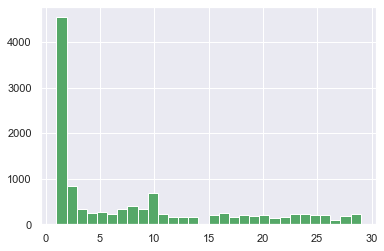

In [104]:
plt.hist(df.yearly_avg_Outstation_checkins,bins=30,color="g")

(array([1349., 2256., 4576., 3184.,  384.,    0.,    0.,    0.,    0.,
          11.]),
 array([ 1. ,  1.9,  2.8,  3.7,  4.6,  5.5,  6.4,  7.3,  8.2,  9.1, 10. ]),
 <BarContainer object of 10 artists>)

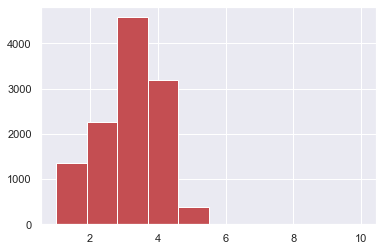

In [108]:
plt.hist(df.member_in_family,color="r")

(array([2884., 2786., 2352.,  892.,  867.,  451.,  420.,  140.,  432.,
         536.]),
 array([ 1009. ,  2914.6,  4820.2,  6725.8,  8631.4, 10537. , 12442.6,
        14348.2, 16253.8, 18159.4, 20065. ]),
 <BarContainer object of 10 artists>)

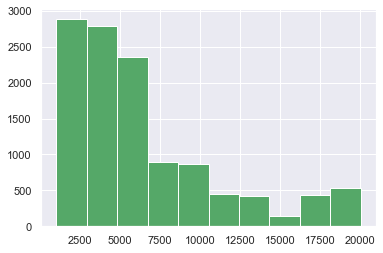

In [109]:
plt.hist(df.total_likes_on_outofstation_checkin_received,color='g')

(array([4102., 1700., 1766., 1118.,  728.,  654.,  594.,  428.,  472.,
         198.]),
 array([ 0. ,  1.1,  2.2,  3.3,  4.4,  5.5,  6.6,  7.7,  8.8,  9.9, 11. ]),
 <BarContainer object of 10 artists>)

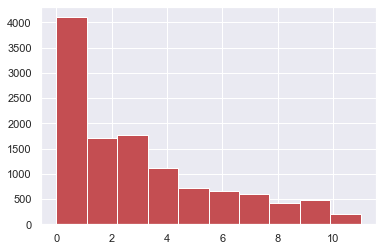

In [110]:
plt.hist(df.week_since_last_outstation_checkin,color='r')

(array([2208.,    0.,    0., 2424.,    0.,    0., 3672.,    0.,    0.,
        3456.]),
 array([1. , 1.3, 1.6, 1.9, 2.2, 2.5, 2.8, 3.1, 3.4, 3.7, 4. ]),
 <BarContainer object of 10 artists>)

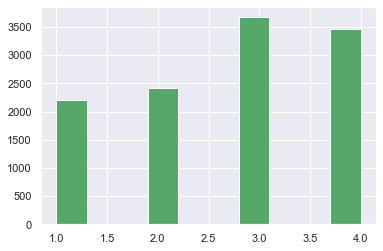

In [112]:
plt.hist(df.travelling_network_rating,color='g')

(array([1.070e+04, 1.056e+03, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 1.000e+00, 1.000e+00]),
 array([  0.,  27.,  54.,  81., 108., 135., 162., 189., 216., 243., 270.]),
 <BarContainer object of 10 artists>)

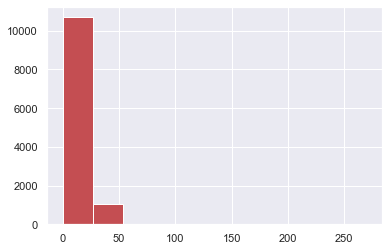

In [115]:
plt.hist(df.Daily_Avg_mins_spend_on_traveling_page,color='r')

C:\Users\lenovo hmin\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Taken_product', ylabel='count'>

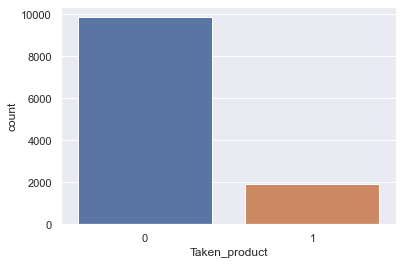

In [116]:
sns.countplot(df["Taken_product"])

C:\Users\lenovo hmin\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='preferred_location_type', ylabel='count'>

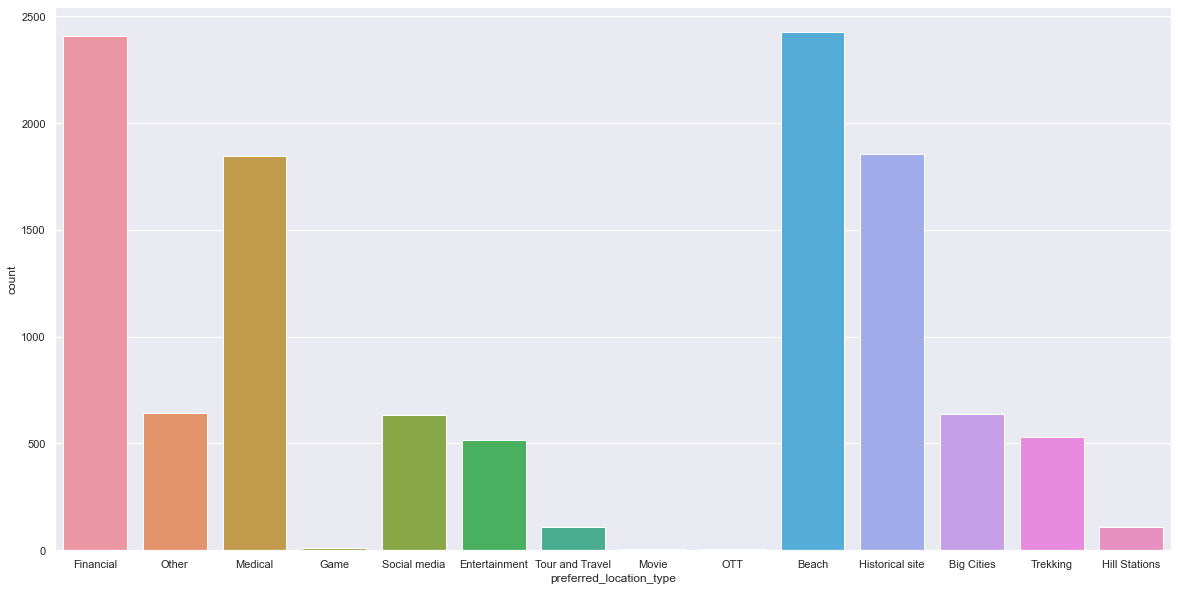

In [119]:
plt.figure(figsize=(20,10))
sns.countplot(df["preferred_location_type"])

In [121]:
x=[1108,10652]
y=["Laptop","Not Laptop"]

([<matplotlib.patches.Wedge at 0x134a1da20d0>,
 [Text(1.0521640713441742, 0.32085941932948076, 'Laptop'),
  Text(-1.0521640413031428, -0.3208595178401891, 'Not Laptop')])

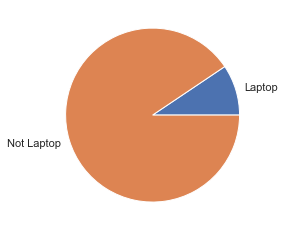

In [122]:
plt.pie(x,labels=y)

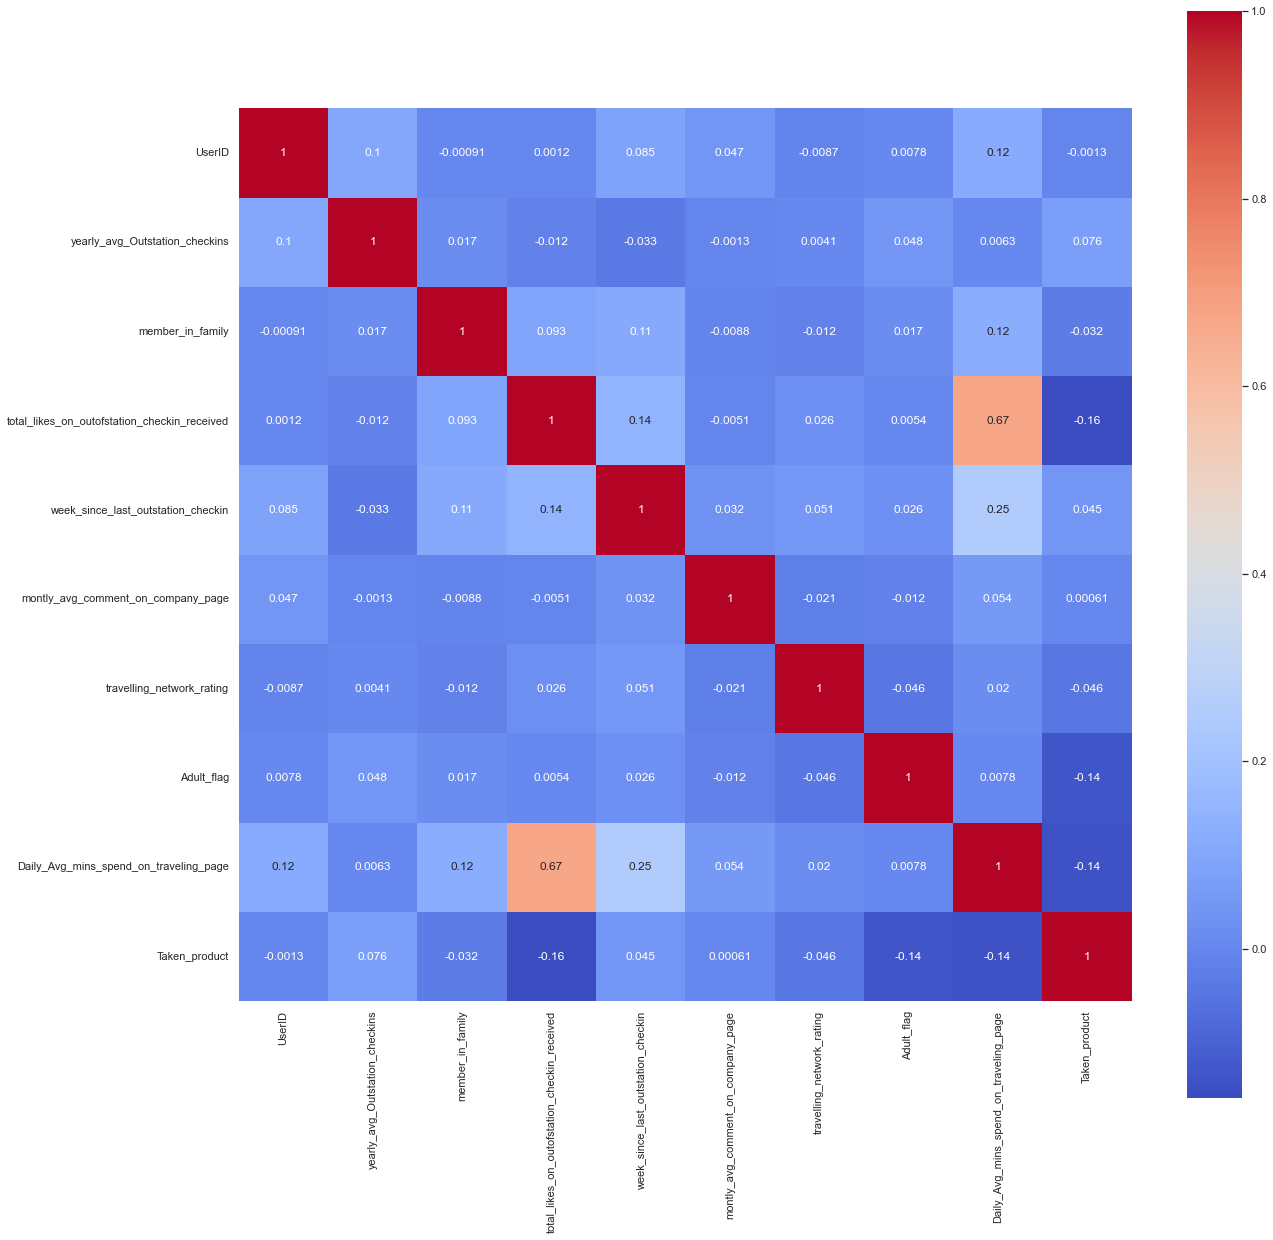

In [123]:
plt.figure(figsize=(20,20))  # setting the size of figure to 12 by 10
p=sns.heatmap(df.corr(), annot=True,cmap='coolwarm',square=True)

3.0     4576
4.0     3184
2.0     2256
1.0     1349
5.0      384
10.0      11
Name: member_in_family, dtype: int64 



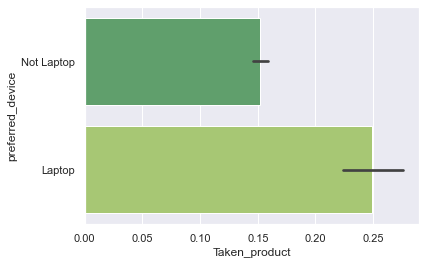

In [49]:
print(df["member_in_family"].value_counts(),'\n')
sns.barplot(x="Taken_product",y="preferred_device",data=df,palette="summer");

<AxesSubplot:xlabel='Taken_product', ylabel='preferred_location_type'>

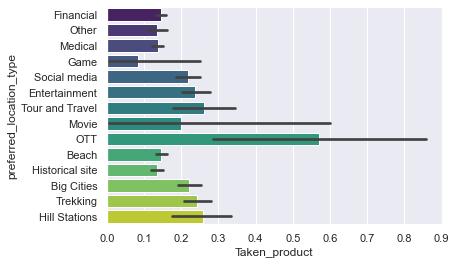

In [58]:
sns.barplot(x="Taken_product",y="preferred_location_type",data=df,palette="viridis")


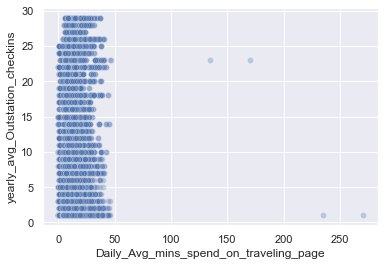

In [60]:
sns.scatterplot(x="Daily_Avg_mins_spend_on_traveling_page",y="yearly_avg_Outstation_checkins",data=df,alpha=0.3);

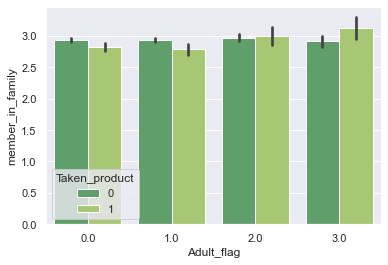

In [63]:
sns.barplot(x="Adult_flag",y="member_in_family",hue=df["Taken_product"],data=df,palette="summer");

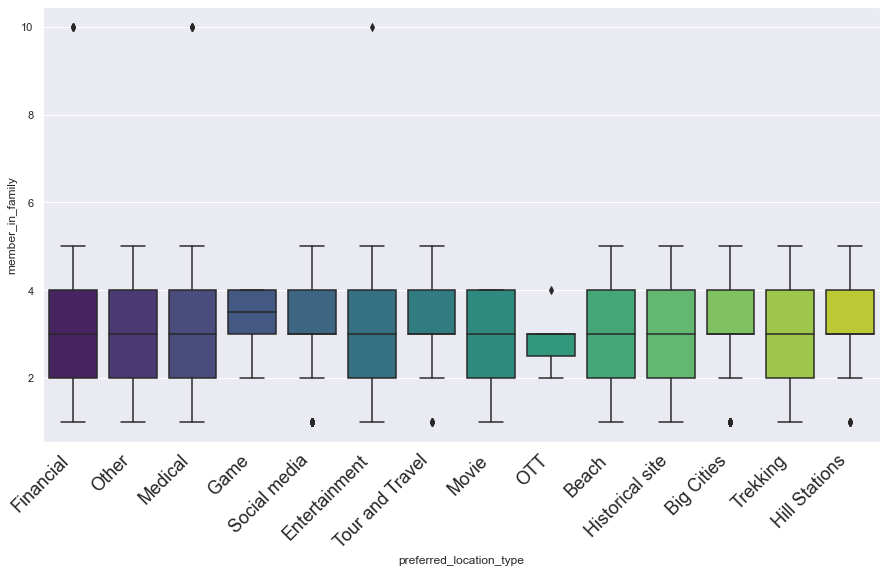

In [71]:
plt.figure(figsize=(15,8))
           
box=sns.boxplot(x="preferred_location_type",y="member_in_family",data=df,palette="viridis")
box.set_xticklabels(box.get_xticklabels(),rotation=45,horizontalalignment='right',fontsize=18)
box;

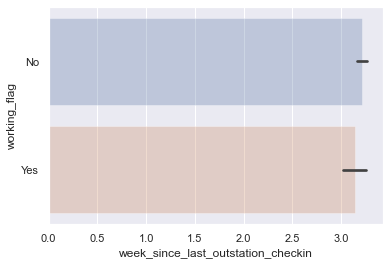

In [73]:
sns.barplot(x="week_since_last_outstation_checkin",y="working_flag",data=df,alpha=0.3);

In [36]:
df.head()

,UserID,yearly_avg_Outstation_checkins,member_in_family,total_likes_on_outofstation_checkin_received,week_since_last_outstation_checkin,montly_avg_comment_on_company_page,travelling_network_rating,Adult_flag,Daily_Avg_mins_spend_on_traveling_page,Taken_product,preferred_device,preferred_location_type,following_company_page,working_flag
0,1000001.0,1.0,2.0,5993.0,8.0,11.0,1.0,0.0,8.0,1,Not Laptop,Financial,Yes,No
1,1000002.0,1.0,1.0,5130.0,1.0,23.0,4.0,1.0,10.0,0,Not Laptop,Financial,No,Yes
2,1000003.0,1.0,2.0,2090.0,6.0,15.0,2.0,0.0,7.0,1,Not Laptop,Other,Yes,No
3,1000004.0,1.0,4.0,2909.0,1.0,11.0,3.0,0.0,8.0,0,Not Laptop,Financial,Yes,No
4,1000005.0,1.0,1.0,3468.0,9.0,12.0,4.0,1.0,6.0,0,Not Laptop,Medical,No,No


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11760 entries, 0 to 11759
Data columns (total 14 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   UserID                                        11760 non-null  float64
 1   yearly_avg_Outstation_checkins                11760 non-null  float64
 2   member_in_family                              11760 non-null  float64
 3   total_likes_on_outofstation_checkin_received  11760 non-null  float64
 4   week_since_last_outstation_checkin            11760 non-null  float64
 5   montly_avg_comment_on_company_page            11760 non-null  float64
 6   travelling_network_rating                     11760 non-null  float64
 7   Adult_flag                                    11760 non-null  float64
 8   Daily_Avg_mins_spend_on_traveling_page        11760 non-null  float64
 9   Taken_product                                 11760 non-null 

In [31]:
#nominal encoding
df.select_dtypes(include='object').head()

,preferred_device,preferred_location_type,following_company_page,working_flag
0,Not Laptop,Financial,Yes,No
1,Not Laptop,Financial,No,Yes
2,Not Laptop,Other,Yes,No
3,Not Laptop,Financial,Yes,No
4,Not Laptop,Medical,No,No


In [32]:
for feature in df.columns: 
    if df[feature].dtype == 'object':
        df[feature] = pd.Categorical(df[feature]).codes

In [33]:
df.dtypes

UserID                                          float64
yearly_avg_Outstation_checkins                  float64
member_in_family                                float64
total_likes_on_outofstation_checkin_received    float64
week_since_last_outstation_checkin              float64
montly_avg_comment_on_company_page              float64
travelling_network_rating                       float64
Adult_flag                                      float64
Daily_Avg_mins_spend_on_traveling_page          float64
Taken_product                                     int32
preferred_device                                   int8
preferred_location_type                            int8
following_company_page                             int8
working_flag                                       int8
dtype: object

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV

In [39]:
#df["Yearly_avg_Outstation_checkins"].unique()
df["yearly_avg_Outstation_checkins"].unique()

array([ 1., 24., 23., 27., 16., 15., 26., 19., 21., 11., 10., 25., 12.,
       18., 29.,  4., 22., 14., 20., 28., 17., 13.,  5.,  8.,  2.,  3.,
        9.,  7.,  6.])

In [35]:
#train-test-split
x=df.drop(['Taken_product'],axis=1)
y=df.Taken_product

In [36]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=123,test_size=0.30)

In [42]:
ss=StandardScaler() 
x_train_scaled=ss.fit_transform(x_train)
x_test_scaled=ss.transform(x_test)

In [55]:
ytrain_predict = model.predict(x_train)
ytest_predict = model.predict(x_test)

In [37]:
from sklearn import metrics
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import confusion_matrix,classification_report

# naive bayes

In [61]:
#naive bayes model
from sklearn.naive_bayes import GaussianNB # using Gaussian algorithm from Naive Bayes
df_model = GaussianNB()

df_model.fit(x_train, y_train.ravel())

GaussianNB()

In [62]:
df_train_predict = df_model.predict(x_train)

from sklearn import metrics

print("Model Accuracy: {0:.4f}".format(metrics.accuracy_score(y_train, df_train_predict)))
print()

Model Accuracy: 0.8342



In [63]:
df_test_predict = df_model.predict(x_test)

from sklearn import metrics

print("Model Accuracy: {0:.4f}".format(metrics.accuracy_score(y_test, df_test_predict)))
print()

Model Accuracy: 0.8209



Confusion Matrix


<AxesSubplot:>

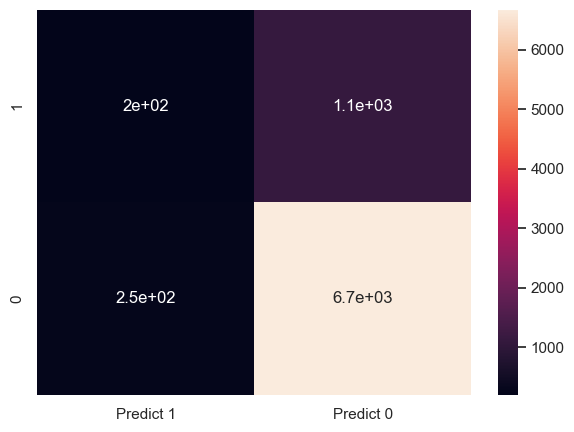

In [66]:
#train set
print("Confusion Matrix")
cm=metrics.confusion_matrix(y_train, df_train_predict, labels=[1, 0])

df_cm = pd.DataFrame(cm, index = [i for i in ["1","0"]],
                  columns = [i for i in ["Predict 1","Predict 0"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=True)

In [67]:
print("Classification Report")
print(metrics.classification_report(y_train, df_train_predict, labels=[1, 0]))

Classification Report
              precision    recall  f1-score   support

           1       0.43      0.15      0.22      1306
           0       0.86      0.96      0.91      6926

    accuracy                           0.83      8232
   macro avg       0.65      0.56      0.56      8232
weighted avg       0.79      0.83      0.80      8232



Confusion Matrix


<AxesSubplot:>

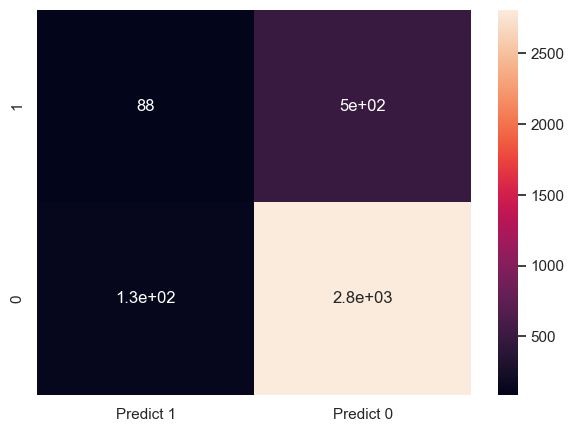

In [64]:
# test set
print("Confusion Matrix")
cm=metrics.confusion_matrix(y_test, df_test_predict, labels=[1, 0])

df_cm = pd.DataFrame(cm, index = [i for i in ["1","0"]],
                  columns = [i for i in ["Predict 1","Predict 0"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=True)

In [65]:
print("Classification Report")
print(metrics.classification_report(y_test, df_test_predict, labels=[1, 0]))

Classification Report
              precision    recall  f1-score   support

           1       0.40      0.15      0.22       590
           0       0.85      0.96      0.90      2938

    accuracy                           0.82      3528
   macro avg       0.63      0.55      0.56      3528
weighted avg       0.77      0.82      0.78      3528



In [69]:
!pip install imbalanced-learn

     -------------------------------------- 226.0/226.0 kB 2.0 MB/s eta 0:00:00
     -------------------------------------- 298.0/298.0 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.0
    Uninstalling joblib-1.1.0:
      Successfully uninstalled joblib-1.1.0


In [70]:
from imblearn.over_sampling import SMOTE

# naive bayes with SMOTE

In [73]:
sm = SMOTE(random_state=2)
x_train_res, y_train_res = sm.fit_resample(x_train, y_train.ravel())

In [74]:
x_train_res.shape

(13852, 13)

In [75]:
NB_SM_model = GaussianNB()
NB_SM_model.fit(x_train_res, y_train_res)

GaussianNB()

In [76]:
# Performance Matrix on train data set with SMOTE
y_train_predict = NB_SM_model.predict(x_train_res)
model_score = NB_SM_model.score(x_train_res, y_train_res)
print(model_score)
print(metrics.confusion_matrix(y_train_res, y_train_predict))
print(metrics.classification_report(y_train_res ,y_train_predict))

0.6477764943690442
[[3598 3328]
 [1551 5375]]
              precision    recall  f1-score   support

           0       0.70      0.52      0.60      6926
           1       0.62      0.78      0.69      6926

    accuracy                           0.65     13852
   macro avg       0.66      0.65      0.64     13852
weighted avg       0.66      0.65      0.64     13852



In [77]:
# Performance Matrix on test data set
y_test_predict = NB_SM_model.predict(x_test)
model_score = NB_SM_model.score(x_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.5498866213151927
[[1531 1407]
 [ 181  409]]
              precision    recall  f1-score   support

           0       0.89      0.52      0.66      2938
           1       0.23      0.69      0.34       590

    accuracy                           0.55      3528
   macro avg       0.56      0.61      0.50      3528
weighted avg       0.78      0.55      0.61      3528



# bagging

In [56]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
cart = DecisionTreeClassifier()
Bagging_model=BaggingClassifier(base_estimator=cart,n_estimators=100,random_state=1)
Bagging_model.fit(x_train, y_train)

BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=100,
                  random_state=1)

In [57]:
# Performance Matrix on train data set
y_train_predict = Bagging_model.predict(x_train)
model_score =Bagging_model.score(x_train, y_train)
print(model_score)
print(metrics.confusion_matrix(y_train, y_train_predict))
print(metrics.classification_report(y_train, y_train_predict))

1.0
[[6926    0]
 [   0 1306]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6926
           1       1.00      1.00      1.00      1306

    accuracy                           1.00      8232
   macro avg       1.00      1.00      1.00      8232
weighted avg       1.00      1.00      1.00      8232



In [58]:
# Performance Matrix on test data set
y_test_predict = Bagging_model.predict(x_test)
model_score = Bagging_model.score(x_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.9725056689342404
[[2930    8]
 [  89  501]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2938
           1       0.98      0.85      0.91       590

    accuracy                           0.97      3528
   macro avg       0.98      0.92      0.95      3528
weighted avg       0.97      0.97      0.97      3528



# gradient boosting classifier

In [38]:
from sklearn.ensemble import GradientBoostingClassifier
gbcl = GradientBoostingClassifier(random_state=1)
gbcl = gbcl.fit(x_train, y_train)

In [39]:
## Performance Matrix on train data set
y_train_predict = gbcl.predict(x_train)
model_score = gbcl.score(x_train, y_train)
print(model_score)
print(metrics.confusion_matrix(y_train, y_train_predict))
print(metrics.classification_report(y_train, y_train_predict))

0.8965014577259475
[[6854   72]
 [ 780  526]]
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      6926
           1       0.88      0.40      0.55      1306

    accuracy                           0.90      8232
   macro avg       0.89      0.70      0.75      8232
weighted avg       0.89      0.90      0.88      8232



In [40]:
## Performance Matrix on test data set
y_test_predict = gbcl.predict(x_test)
model_score = gbcl.score(x_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.8843537414965986
[[2898   40]
 [ 368  222]]
              precision    recall  f1-score   support

           0       0.89      0.99      0.93      2938
           1       0.85      0.38      0.52       590

    accuracy                           0.88      3528
   macro avg       0.87      0.68      0.73      3528
weighted avg       0.88      0.88      0.87      3528



In [51]:
from sklearn.experimental import enable_halving_search_cv 
from sklearn.model_selection import HalvingGridSearchCV

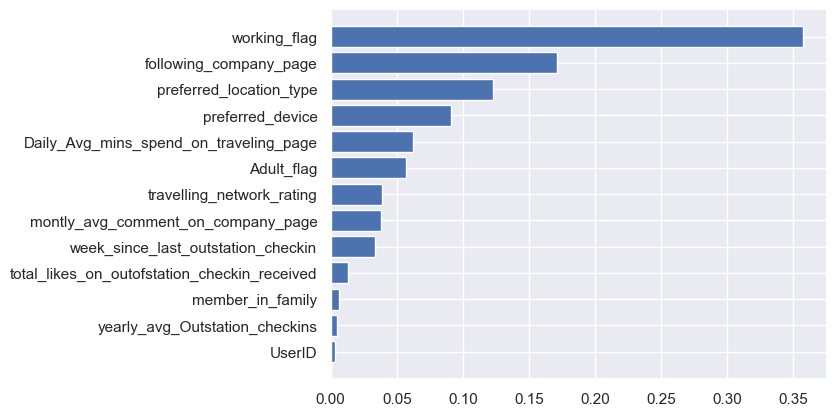

In [45]:
sorted_idx = gbcl.feature_importances_.argsort()
plt.barh(x_train.columns,gbcl.feature_importances_[sorted_idx])

plt.show()

In [72]:
from sklearn.ensemble import RandomForestClassifier

RF_model=RandomForestClassifier(n_estimators=100,random_state=1)
RF_model.fit(x_train, y_train)

RandomForestClassifier(random_state=1)

# random forest classifier

In [73]:
## Performance Matrix on train data set
y_train_predict = RF_model.predict(x_train)
model_score =RF_model.score(x_train, y_train)
print(model_score)
print(metrics.confusion_matrix(y_train, y_train_predict))
print(metrics.classification_report(y_train, y_train_predict))

1.0
[[6926    0]
 [   0 1306]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6926
           1       1.00      1.00      1.00      1306

    accuracy                           1.00      8232
   macro avg       1.00      1.00      1.00      8232
weighted avg       1.00      1.00      1.00      8232



In [74]:
## Performance Matrix on test data set
y_test_predict = RF_model.predict(x_test)
model_score = RF_model.score(x_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.9546485260770975
[[2933    5]
 [ 155  435]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      2938
           1       0.99      0.74      0.84       590

    accuracy                           0.95      3528
   macro avg       0.97      0.87      0.91      3528
weighted avg       0.96      0.95      0.95      3528



Text(0.5, 0, 'Random Forest Feature Importance')

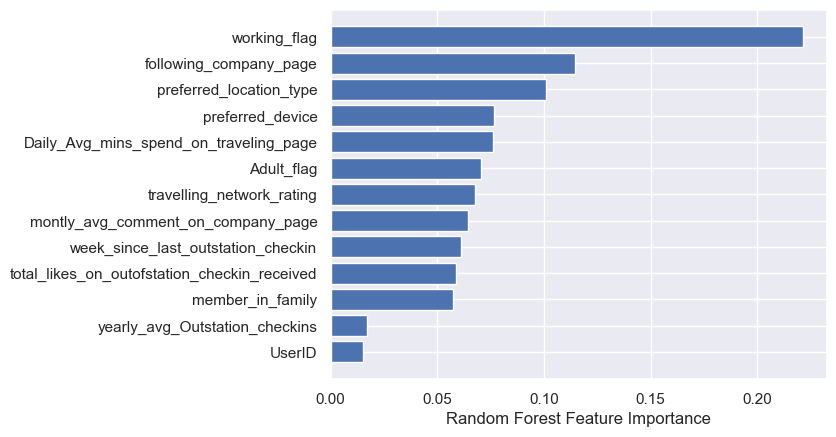

In [75]:
sorted_idx = RF_model.feature_importances_.argsort()
plt.barh(x_train.columns,RF_model.feature_importances_[sorted_idx])
plt.xlabel("Random Forest Feature Importance")